--- Department Analysis ---
shape: (4, 3)
┌────────────┬──────────────┬──────────────────┐
│ Department ┆ Avg_Salary   ┆ Best_Performance │
│ ---        ┆ ---          ┆ ---              │
│ str        ┆ f64          ┆ f64              │
╞════════════╪══════════════╪══════════════════╡
│ IT         ┆ 69846.4      ┆ 9.168098         │
│ Sales      ┆ 72649.384615 ┆ 9.367279         │
│ HR         ┆ 65569.0      ┆ 9.064822         │
│ Marketing  ┆ 63737.1875   ┆ 9.033031         │
└────────────┴──────────────┴──────────────────┘

--- Top 5 Highest Salaries ---
shape: (5, 6)
┌──────────┬────────────┬────────┬─────────────┬─────┬───────────┐
│ Employee ┆ Department ┆ Salary ┆ Performance ┆ Age ┆ Rating    │
│ ---      ┆ ---        ┆ ---    ┆ ---         ┆ --- ┆ ---       │
│ str      ┆ str        ┆ i32    ┆ f64         ┆ i32 ┆ str       │
╞══════════╪════════════╪════════╪═════════════╪═════╪═══════════╡
│ Emp_19   ┆ Sales      ┆ 99479  ┆ 7.847065    ┆ 58  ┆ Excellent │
│ Emp_6    ┆ IT     

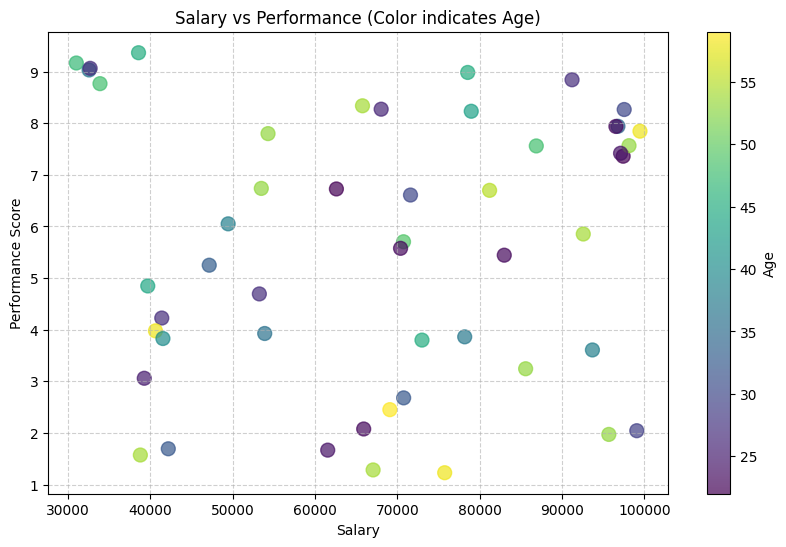


--- Top IT Performers ---
shape: (5, 6)
┌──────────┬────────────┬────────┬─────────────┬─────┬───────────┐
│ Employee ┆ Department ┆ Salary ┆ Performance ┆ Age ┆ Rating    │
│ ---      ┆ ---        ┆ ---    ┆ ---         ┆ --- ┆ ---       │
│ str      ┆ str        ┆ i32    ┆ f64         ┆ i32 ┆ str       │
╞══════════╪════════════╪════════╪═════════════╪═════╪═══════════╡
│ Emp_2    ┆ IT         ┆ 86886  ┆ 7.561065    ┆ 48  ┆ Excellent │
│ Emp_7    ┆ IT         ┆ 33890  ┆ 8.767931    ┆ 48  ┆ Excellent │
│ Emp_15   ┆ IT         ┆ 78555  ┆ 8.984915    ┆ 45  ┆ Excellent │
│ Emp_21   ┆ IT         ┆ 96557  ┆ 7.938705    ┆ 23  ┆ Excellent │
│ Emp_31   ┆ IT         ┆ 31016  ┆ 9.168098    ┆ 47  ┆ Excellent │
└──────────┴────────────┴────────┴─────────────┴─────┴───────────┘


In [1]:
# Day_14.ipynb Learn polars basic and intermediate level
# Complex dataset
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# 1. Dataset Creation (With Age column included)
data = {
    "Employee": [f"Emp_{i}" for i in range(50)],
    "Department": np.random.choice(["IT", "HR", "Sales", "Marketing"], 50),
    "Salary": np.random.randint(30000, 100000, 50),
    "Performance": np.random.uniform(1, 10, 50),
    "Age": np.random.randint(22, 60, 50)
}
df = pl.DataFrame(data)

# 2. Performance ke basis pe 'Rating' column add karna
df = df.with_columns(
    pl.when(pl.col("Performance") > 7).then(pl.lit("Excellent"))
    .otherwise(pl.lit("Good"))
    .alias("Rating")
)

# 3. Aggregation: Department wise Analysis
analysis = df.group_by("Department").agg([
    pl.col("Salary").mean().alias("Avg_Salary"),
    pl.col("Performance").max().alias("Best_Performance")
])
print("--- Department Analysis ---")
print(analysis)

# 4. Sorting: Highest salary
sorted_df = df.sort("Salary", descending=True)
print("\n--- Top 5 Highest Salaries ---")
print(sorted_df.head(5))

# 5. Visualizing the Insights
plt.figure(figsize=(10, 6))
# Using to_numpy() to ensure data compatibility with matplotlib
plt.scatter(df["Salary"].to_numpy(), df["Performance"].to_numpy(), 
            c=df["Age"].to_numpy(), cmap='viridis', s=100, alpha=0.7)
plt.colorbar(label="Age")
plt.title("Salary vs Performance (Color indicates Age)")
plt.xlabel("Salary")
plt.ylabel("Performance Score")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 7. Filtering complex data
top_it_performers = df.filter(
    (pl.col("Department") == "IT") & 
    (pl.col("Rating") == "Excellent")
)
print("\n--- Top IT Performers ---")
print(top_it_performers)